# Task dynamic simulations

This notebook demonstrates task dynamic simulations using a second-order critically-damped mass-spring system (Saltzman & Munhall 1989). This generates smooth tract variable trajectories from discrete gestural specifications. Each gesture defines a target position, spring stiffness, and an activation window. When gestures overlap, their parameters are blended via alpha-weighted averaging. A neutral attractor (target=0) governs the system when no gesture is active.

Note that this analysis is to demonstrate task dynamic simulations **without** dynamic neural fields as an input. For an example of using the output of a DNF to drive the task dynamic equation target see `examples/single_field.ipynb`.

In [1]:
from pyphonplan import TaskDynamics

## Initialise the simulation

Set up a task dynamic system with start/end times, an initial position, and an integration time-step. If `t_end` exceeds the final gesture end time, the tract variable will return to a neutral value of 0. To avoid this, make sure that `t_end` matches the final gesture end time.

In [2]:
td = TaskDynamics(t_start=0.0, t_end=0.6, dt=0.001, initial_position=0.0)

## Add gestures

Add two gestures with different targets, stiffnesses, timings and alpha weights. Remember that our initial position defined above was 0, so the targets must be non-zero to exhibit any movement from this initial state. The alpha ratio controls blending during overlap — here, a ratio of 1:100 means gesture 2 dominates during the overlap window.

In [3]:
td.add_gesture(target=5.0, k=2000.0, alpha=1, start=0.05, end=0.25)
td.add_gesture(target=-5.0, k=2000.0, alpha=100, start=0.15, end=0.40)

Gesture(target=-5.0, k=2000.0, damping=np.float64(89.44271909999159), start=0.15, end=0.4, alpha=100)

## Solve

Integrate the second-order ODE and solve for the position and velocity of the system. The system is critically damped, so the tract variable approaches each target smoothly without oscillation.

In [4]:
td.solve()

## Plot tract variable and velocity

The top panel shows the tract variable (position) over time. The bottom panel shows absolute velocity, which peaks during transitions between gestural targets. If you want raw (non-absolute) velocity then just specify `abs_velocity=False`.

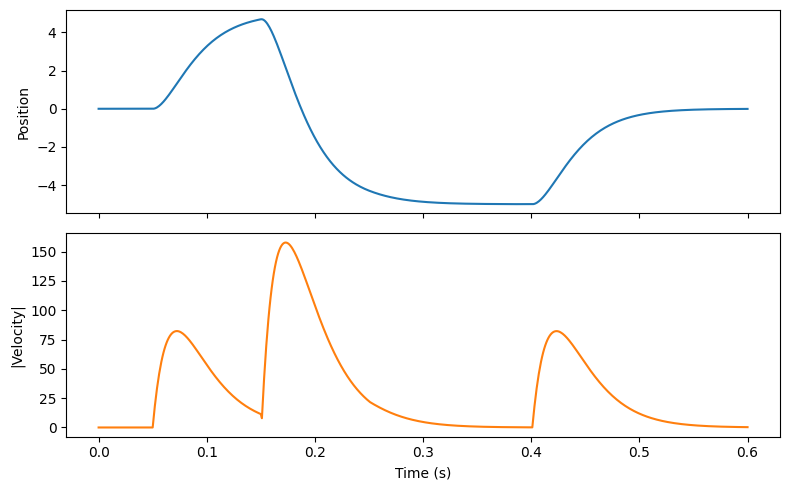

In [5]:
td.plot(abs_velocity=True);

## Plot blended parameters

`plot_params()` will plot the effective target, stiffness, and damping values at each time step, after alpha-weighted blending of all active gestures. Outside any gesture activation window, the neutral attractor (target=0) takes over.

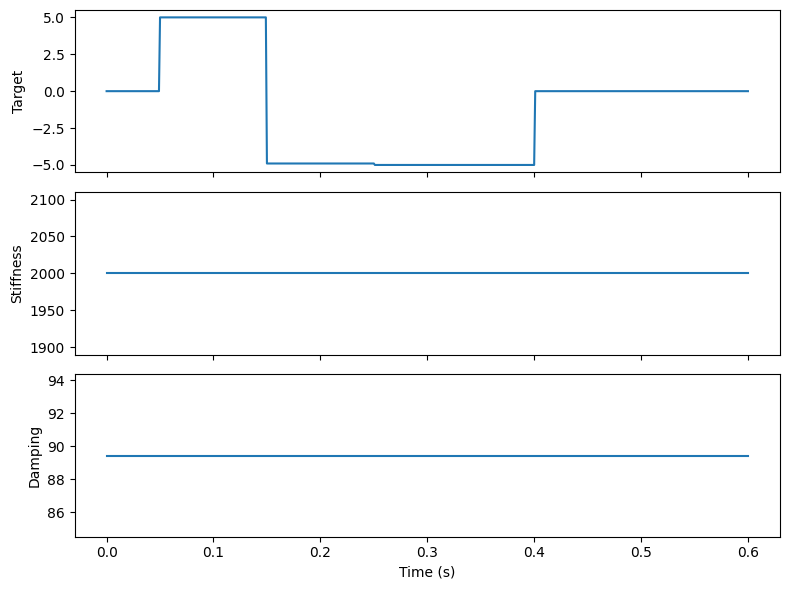

In [6]:
td.plot_params();

We can also select a subset of parameters to plot, if we only want to look at one or two parameters.

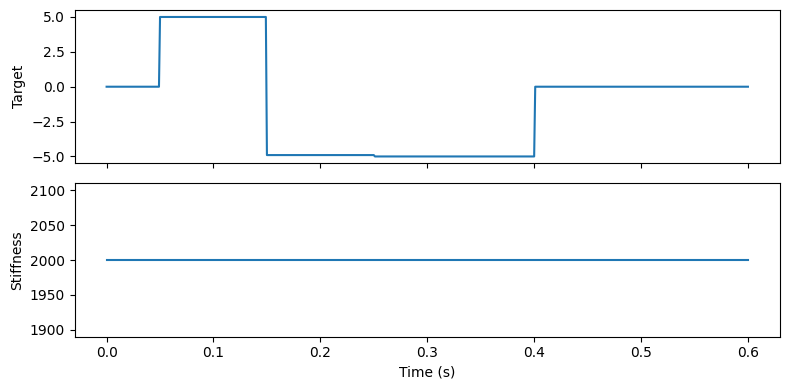

In [7]:
td.plot_params(params=["target", "k"]);